# Итоговый проект

Цель проекта — выявить аномальное поведение пользователей для предотвращения инсайдерских угроз и нарушений комплаенса.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
import matplotlib.pyplot as plt

# Первичный анализ структуры данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FILE_PATH = '/content/drive/MyDrive/ВШЭ/2 семестр/Технологии искусственного интеллекта и продвинутой аналитики/Итоговый проект/compliance.csv'
df = pd.read_csv(FILE_PATH, sep=',', engine='python')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   action_datetime  60000 non-null  object
 1   user_id          60000 non-null  int64 
 2   action_type      60000 non-null  object
 3   object_type      60000 non-null  object
 4   object_id        60000 non-null  int64 
 5   is_emergency     60000 non-null  int64 
 6   comment          29949 non-null  object
dtypes: int64(3), object(4)
memory usage: 3.2+ MB


**Описание датасета**

Это журнал аудита действий пользователей корпоративной информационной системы.
*   Объем: 60 000 записей.
*   Субъекты: 100 уникальных пользователей (user_id).
*   Структура данных: Каждая запись содержит временную метку, ID пользователя, тип действия (создание, изменение, удаление, активация/деактивация), тип объекта (требования, отчеты, ролевые модели, нормативные акты), признак аварийного режима (is_emergency) и текстовый комментарий.

In [ ]:
df

,action_datetime,user_id,action_type,object_type,object_id,is_emergency,comment
0,2024-06-19 11:29:41,38,DELETE,требование,29833,0,Ошибочное создание
1,2023-03-20 06:26:20,5,ACTIVATE,ролевая модель,12929,0,NaN
2,2023-01-06 16:27:43,73,INSERT,нормативный акт,12272,1,Создание нового элемента
3,2023-06-05 07:36:41,50,UPDATE,требование,21460,0,Актуализация версии
4,2025-11-14 00:28:59,25,INSERT,нормативный акт,14084,1,Создание нового элемента
...,...,...,...,...,...,...,...
59995,2023-09-17 14:05:56,5,UPDATE,требование,822,1,Актуализация версии
59996,2025-12-11 01:43:46,22,DEACTIVATE,отчет,27514,0,NaN
59997,2023-02-08 16:52:59,58,DEACTIVATE,отчет,7372,0,NaN
59998,2024-11-14 05:24:59,64,ACTIVATE,требование,6011,0,NaN


Базовые числовые статистики

In [ ]:
df.describe()

,user_id,object_id,is_emergency
count,60000.000000,60000.000000,60000.000000
mean,43.446433,15026.495250,0.280400
std,28.881448,8910.751013,0.449198
min,1.000000,100.000000,0.000000
25%,20.000000,8345.000000,0.000000
50%,44.000000,14703.000000,0.000000
75%,70.000000,22238.000000,1.000000
max,100.000000,30298.000000,1.000000


Распределение категориальных признаков

In [ ]:
print("\nТипы действий (action_type):")
print(df['action_type'].value_counts(normalize=True).round(3))

print("\nТипы объектов (object_type):")
print(df['object_type'].value_counts(normalize=True).round(3))


Типы действий (action_type):
action_type
ACTIVATE      0.251
DEACTIVATE    0.250
UPDATE        0.201
INSERT        0.200
DELETE        0.098
Name: proportion, dtype: float64

Типы объектов (object_type):
object_type
требование         0.348
отчет              0.250
ролевая модель     0.201
нормативный акт    0.200
Name: proportion, dtype: float64


# Предобработка данных и Feature Engineering

Преобразуем даты, создаем новые признаки для анализа (признак рабочего времени, признак ночного времени, признак выходной день, длину комментария, признак наличия критического действия), обрабатываем пропуски в комментариях.

In [ ]:
df['action_datetime'] = pd.to_datetime(df['action_datetime'], errors='coerce')
df['hour'] = df['action_datetime'].dt.hour  # Час суток (0-23)
df['day_of_week'] = df['action_datetime'].dt.dayofweek  # День недели (0=пн, 6=вс)

def is_business_hours(row):
    # dayofweek: 0-4 = пн-пт, 5-6 = сб-вс
    is_weekday = row['day_of_week'] < 5
    is_work_hour = 9 <= row['hour'] < 18
    return is_weekday and is_work_hour

df['is_business_hours'] = df.apply(is_business_hours, axis=1) # Рабочее время: понедельник-пятница, 9:00-18:00

# Создание признака ночное время (00:00-06:00)
df['is_night'] = df['hour'].isin([0, 1, 2, 3, 4, 5])

# Создание признака выходной день
df['is_weekend'] = df['day_of_week'] >= 5

In [ ]:
# Обработка поля comment: заполняем пустые значения
df['comment'] = df['comment'].fillna('')
df['has_comment'] = df['comment'].str.len() > 0  # Есть ли комментарий
df['comment_length'] = df['comment'].str.len()  # Длина комментария

In [ ]:
# Создание признака критическое действие (DELETE, DEACTIVATE)
critical_actions = ['DELETE', 'DEACTIVATE']
df['is_critical'] = df['action_type'].isin(critical_actions)

# Агрегация данных на уровне пользователей

Для выявления аномалий нам необходимо перейти от уровня отдельных событий к уровню пользователей. Мы агрегируем данные, рассчитывая ключевые метрики поведения для каждого `user_id`.

In [ ]:
# Агрегация метрик по пользователям
user_stats = df.groupby('user_id').agg(
    total_actions=('action_datetime', 'count'),
    unique_objects=('object_id', 'nunique'),
    emergency_count=('is_emergency', 'sum'),
    business_count=('is_business_hours', 'sum'),
    commented_count=('has_comment', 'sum'),
    critical_count=('is_critical', 'sum'),
    night_count=('is_night', 'sum')
).reset_index()

# Расчет долей (ratio)
user_stats['emergency_ratio'] = (user_stats['emergency_count'] / user_stats['total_actions']).round(3)
user_stats['business_ratio'] = (user_stats['business_count'] / user_stats['total_actions']).round(3)
user_stats['commented_ratio'] = (user_stats['commented_count'] / user_stats['total_actions']).round(3)
user_stats['critical_ratio'] = (user_stats['critical_count'] / user_stats['total_actions']).round(3)
user_stats['night_ratio'] = (user_stats['night_count'] / user_stats['total_actions']).round(3)

# Инвертированные признаки для удобства расчета риска (чем больше, тем хуже)
user_stats['no_comment_ratio'] = 1 - user_stats['commented_ratio']
user_stats['non_business_ratio'] = 1 - user_stats['business_ratio']

display(user_stats.head())

,user_id,total_actions,unique_objects,emergency_count,business_count,commented_count,critical_count,night_count,emergency_ratio,business_ratio,commented_ratio,critical_ratio,night_ratio,no_comment_ratio,non_business_ratio
0,1,1638,264,444,424,794,569,419,0.271,0.259,0.485,0.347,0.256,0.515,0.741
1,2,309,230,95,74,152,117,91,0.307,0.239,0.492,0.379,0.294,0.508,0.761
2,3,343,242,91,88,169,126,84,0.265,0.257,0.493,0.367,0.245,0.507,0.743
3,4,2407,235,687,674,1253,841,597,0.285,0.280,0.521,0.349,0.248,0.479,0.720
4,5,3920,234,1104,1024,1927,1374,1011,0.282,0.261,0.492,0.351,0.258,0.508,0.739


Оценка соотношений внутри типов действий и объектов


In [ ]:
def print_distribution(series, title):
    counts = series.value_counts()
    percents = (series.value_counts(normalize=True) * 100).round(1)
    summary = pd.DataFrame({'Кол-во': counts, '%': percents})
    print(f"\n{title}:")
    print(summary.to_string())

print_distribution(df['action_type'], "Типы действий")
print_distribution(df['object_type'], "Типы объектов")


Типы действий:
             Кол-во     %
action_type              
ACTIVATE      15065  25.1
DEACTIVATE    14986  25.0
UPDATE        12035  20.1
INSERT        12025  20.0
DELETE         5889   9.8

Типы объектов:
                 Кол-во     %
object_type                  
требование        20904  34.8
отчет             14986  25.0
ролевая модель    12085  20.1
нормативный акт   12025  20.0


Количество чрезвычайных изменений

In [ ]:
em_sum = df['is_emergency'].sum()
em_total = len(df)
print(f"Emergency: {em_sum} ({em_sum/em_total*100:.1f}%) из {em_total} записей")

Emergency: 16824 (28.0%) из 60000 записей


# Описательная статистика и визуализация распределений

Статистика активности пользователей:
Среднее количество действий: 600.0
Медиана: 318.0
Максимум: 3920.0
Стд. отклонение: 789.73


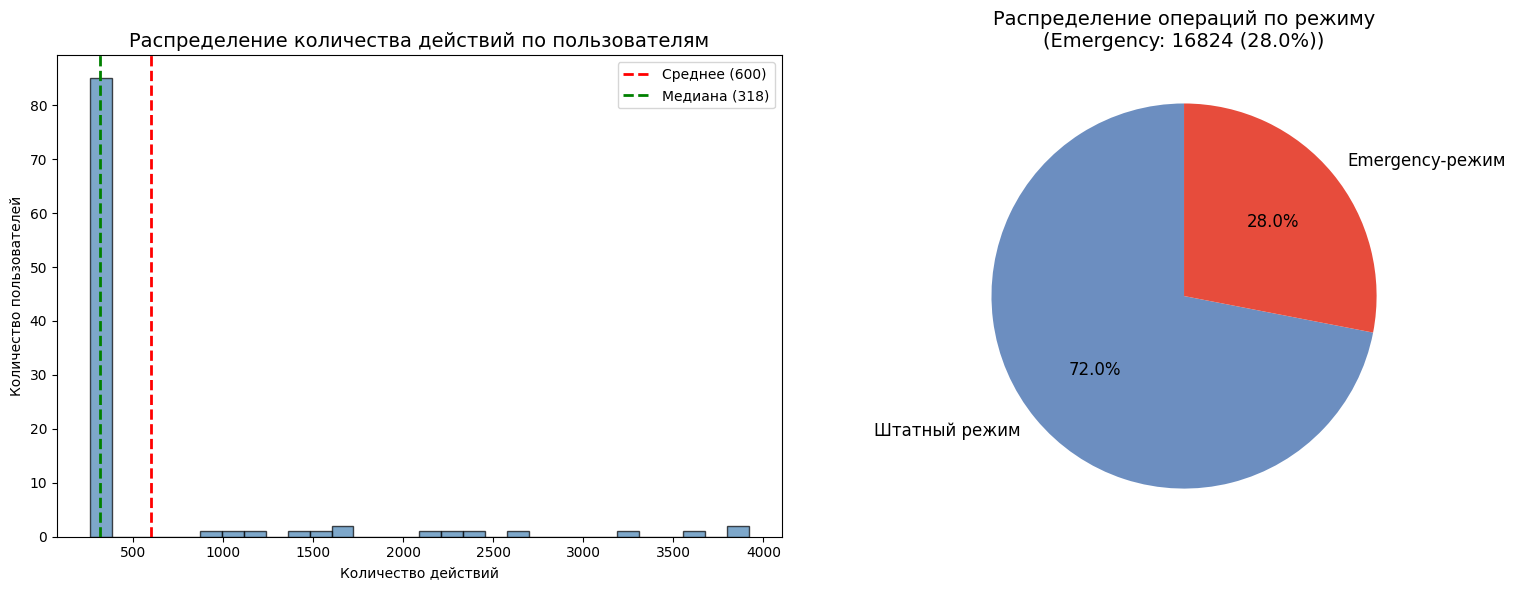

In [ ]:
# Статистики по количеству действий
desc = user_stats['total_actions'].describe()
print(f"Статистика активности пользователей:")
print(f"Среднее количество действий: {desc['mean']:.1f}")
print(f"Медиана: {desc['50%']:.1f}")
print(f"Максимум: {desc['max']}")
print(f"Стд. отклонение: {desc['std']:.2f}")

# Визуализация распределения активности
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма активности
axes[0].hist(user_stats['total_actions'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(user_stats['total_actions'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее ({desc["mean"]:.0f})')
axes[0].axvline(user_stats['total_actions'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана ({desc["50%"]:.0f})')
axes[0].set_title('Распределение количества действий по пользователям', fontsize=14)
axes[0].set_xlabel('Количество действий')
axes[0].set_ylabel('Количество пользователей')
axes[0].legend()

# Pie Chart Emergency режима
em_sum = df['is_emergency'].sum()
em_total = len(df)
sizes = [em_total - em_sum, em_sum]
labels = ['Штатный режим', 'Emergency-режим']
colors = ['#6c8ec0', '#e74c3c']

axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
axes[1].set_title(f'Распределение операций по режиму\n(Emergency: {em_sum} ({em_sum/em_total*100:.1f}%))', fontsize=14)

plt.tight_layout()
plt.show()

# Проверка нормальности распределения признаков

Перед выбором модели машинного обучения необходимо проверить распределение признаков. Методы, основанные на расстоянии (например, Mahalanobis), требуют нормальности, тогда как древовидные методы (Isolation Forest) — нет. Используем тест Шапиро-Уилка и Q-Q plots.

ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ

1. ТЕСТ ШАПИРО-УИЛКА:
--------------------------------------------------------------------------------
Признак                   W-статистика    p-value         Нормальное?    
--------------------------------------------------------------------------------
total_actions             0.4405          0.0000          Нет            
emergency_ratio           0.9844          0.2853          Да             
commented_ratio           0.9933          0.9066          Да             
critical_ratio            0.9765          0.0705          Да             
night_ratio               0.9649          0.0091          Нет            

Вывод: При p-value < 0.05 гипотеза о нормальности отвергается


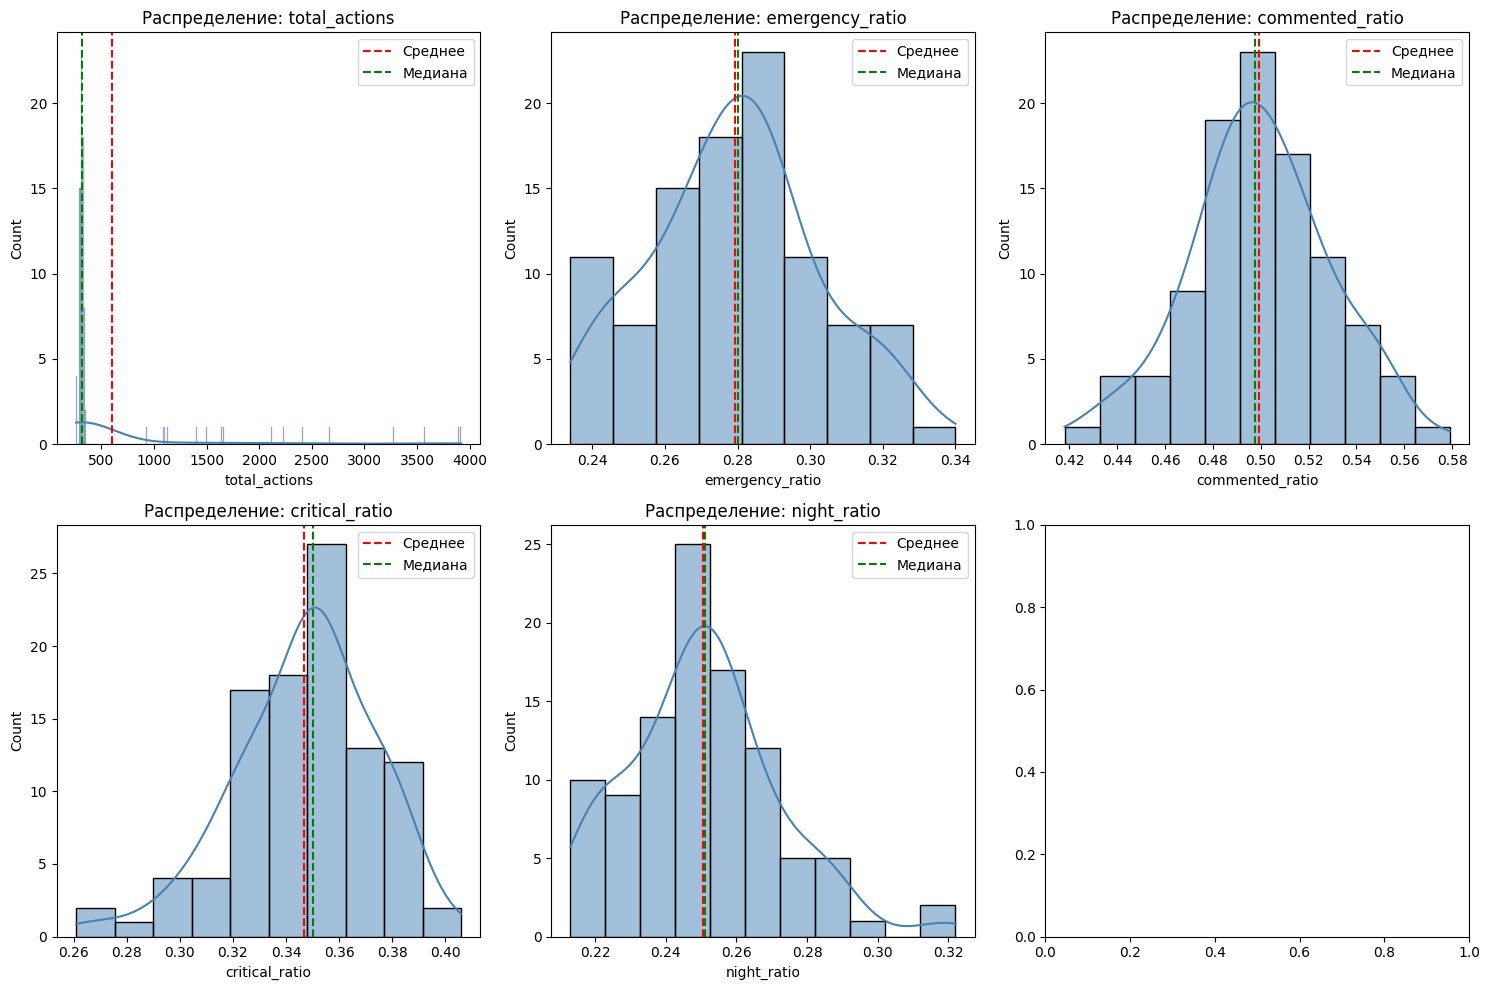

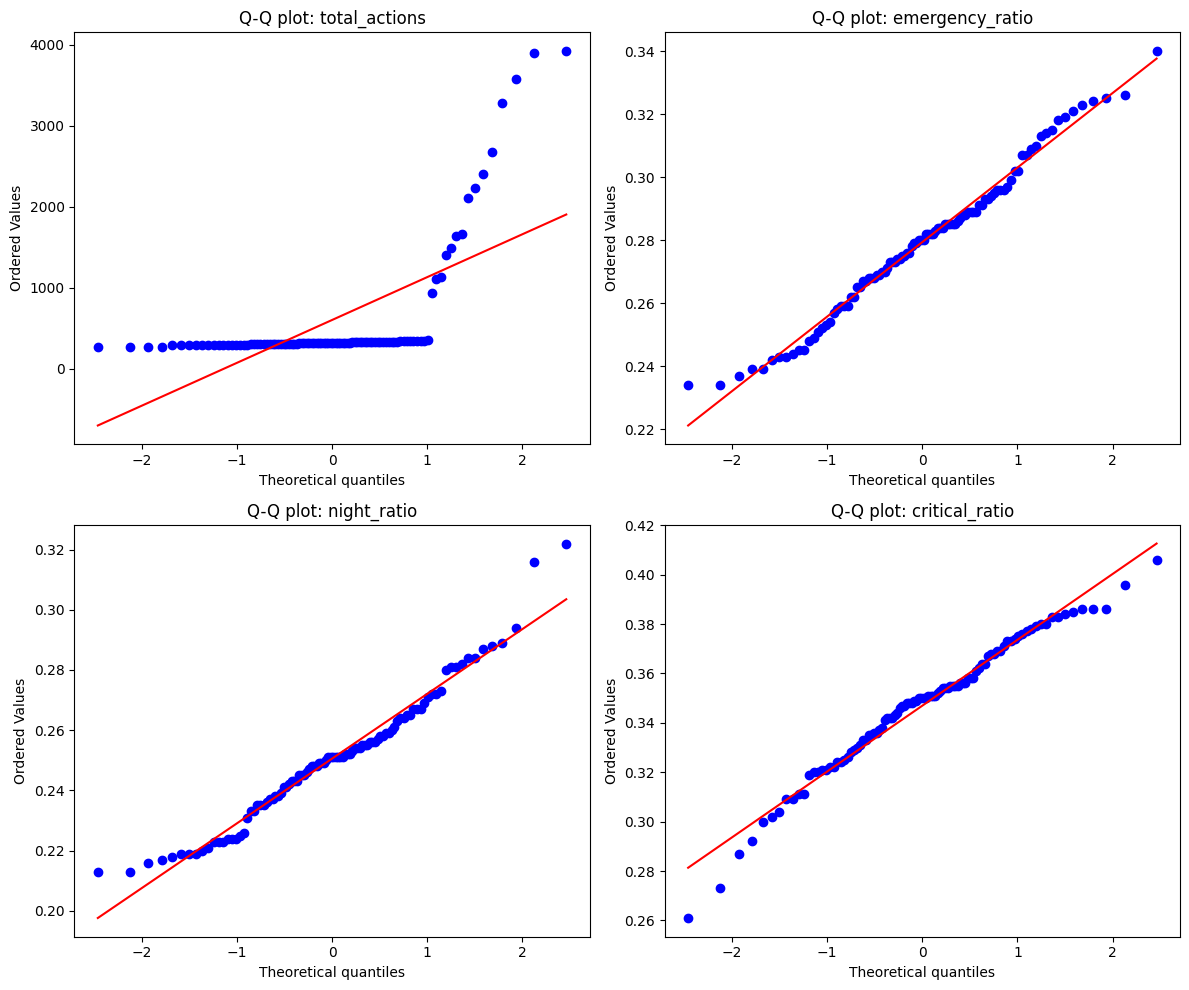


2. ВИЗУАЛЬНЫЙ АНАЛИЗ:
--------------------------------------------------------------------------------
Проверьте гистограммы и Q-Q plots:
• Если точки на Q-Q plot лежат на прямой - распределение близко к нормальному
• Сильные отклонения от прямой указывают на отклонение от нормальности


In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Признаки для проверки
features_to_check = ['total_actions', 'emergency_ratio', 'commented_ratio',
                     'critical_ratio', 'night_ratio']

print("=" * 80)
print("ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ")
print("=" * 80)

# Тест Шапиро-Уилка
print("\n1. ТЕСТ ШАПИРО-УИЛКА:")
print("-" * 80)
print(f"{'Признак':<25} {'W-статистика':<15} {'p-value':<15} {'Нормальное?':<15}")
print("-" * 80)

normality_results = {}
for feature in features_to_check:
    stat, p_value = stats.shapiro(user_stats[feature])
    is_normal = p_value > 0.05
    normality_results[feature] = is_normal
    print(f"{feature:<25} {stat:<15.4f} {p_value:<15.4f} {'Да' if is_normal else 'Нет':<15}")

print("\nВывод: При p-value < 0.05 гипотеза о нормальности отвергается")

# Визуализация распределений
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_check):
    # Гистограмма с KDE
    sns.histplot(user_stats[feature], kde=True, ax=axes[idx], color='steelblue')
    axes[idx].axvline(user_stats[feature].mean(), color='red', linestyle='--', label='Среднее')
    axes[idx].axvline(user_stats[feature].median(), color='green', linestyle='--', label='Медиана')
    axes[idx].set_title(f'Распределение: {feature}')
    axes[idx].legend()

    # Добавляем Q-Q plot
    # (можно добавить отдельным графиком если нужно)

plt.tight_layout()
plt.show()

# Q-Q plot для ключевых признаков
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

key_features = ['total_actions', 'emergency_ratio', 'night_ratio', 'critical_ratio']
for idx, feature in enumerate(key_features):
    stats.probplot(user_stats[feature], dist="norm", plot=axes[idx])
    axes[idx].set_title(f'Q-Q plot: {feature}')

plt.tight_layout()
plt.show()

print("\n2. ВИЗУАЛЬНЫЙ АНАЛИЗ:")
print("-" * 80)
print("Проверьте гистограммы и Q-Q plots:")
print("• Если точки на Q-Q plot лежат на прямой - распределение близко к нормальному")
print("• Сильные отклонения от прямой указывают на отклонение от нормальности")
print("=" * 80)

# Статистический метод детекции аномалий (IQR)

Используем межквартильный размах (IQR) для выявления пользователей с экстремально высокой активностью. Этот метод устойчив к выбросам и не требует предположения о нормальности распределения.

In [ ]:
# Расчет квартилей для total_actions
Q1 = user_stats['total_actions'].quantile(0.25)
Q3 = user_stats['total_actions'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Границы выбросов по методу IQR (Total Actions):")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Верхняя граница (Upper Bound): {upper_bound:.2f}")

# Выявление выбросов по активности
outliers_iqr = user_stats[user_stats['total_actions'] > upper_bound]
print(f"\nКоличество пользователей с аномально высокой активностью (> {upper_bound:.0f}): {len(outliers_iqr)}")

# Также выделим пользователей, превышающих пороги по другим метрикам
# Пороги: Emergency > 30%, Night > 25%, No Comment Critical > 50%
high_emergency = user_stats[user_stats['emergency_ratio'] > 0.30]
high_night = user_stats[user_stats['night_ratio'] > 0.25]
high_no_comment = user_stats[user_stats['no_comment_ratio'] > 0.50]

print(f"Пользователи с высокой долей Emergency (>30%): {len(high_emergency)}")
print(f"Пользователи с высокой долей ночной активности (>25%): {len(high_night)}")
print(f"Пользователи с высокой долей действий без комментария (>50%): {len(high_no_comment)}")

Границы выбросов по методу IQR (Total Actions):
Q1: 305.00, Q3: 332.50, IQR: 27.50
Верхняя граница (Upper Bound): 373.75

Количество пользователей с аномально высокой активностью (> 374): 15
Пользователи с высокой долей Emergency (>30%): 17
Пользователи с высокой долей ночной активности (>25%): 52
Пользователи с высокой долей действий без комментария (>50%): 52


# Композитный индекс риска (CRS)
Для комплексной оценки мы нормализуем метрики и рассчитываем взвешенный индекс риска. Это позволяет ранжировать пользователей по степени потенциальной угрозы, учитывая несколько факторов одновременно.

In [ ]:
# Функция Min-Max нормализации
def normalize_series(series):
    min_val = series.min()
    max_val = series.max()
    if max_val - min_val == 0:
        return pd.Series(0, index=series.index)
    return (series - min_val) / (max_val - min_val)

# Нормализация признаков риска
user_stats['norm_actions'] = normalize_series(user_stats['total_actions'])
user_stats['norm_emergency'] = normalize_series(user_stats['emergency_ratio'])
user_stats['norm_no_comment'] = normalize_series(user_stats['no_comment_ratio'])
user_stats['norm_night'] = normalize_series(user_stats['night_ratio'])
user_stats['norm_critical'] = normalize_series(user_stats['critical_ratio'])

# Весовые коэффициенты
weights = {
    'norm_actions': 0.20,
    'norm_emergency': 0.25,
    'norm_no_comment': 0.20,
    'norm_night': 0.15,
    'norm_critical': 0.20
}

# Расчет CRS
user_stats['risk_score'] = (
    user_stats['norm_actions'] * weights['norm_actions'] +
    user_stats['norm_emergency'] * weights['norm_emergency'] +
    user_stats['norm_no_comment'] * weights['norm_no_comment'] +
    user_stats['norm_night'] * weights['norm_night'] +
    user_stats['norm_critical'] * weights['norm_critical']
).round(3)

# Категоризация риска
def risk_category(score):
    if score >= 0.7: return 'КРИТИЧЕСКИЙ'
    elif score >= 0.45: return 'ВЫСОКИЙ'
    elif score >= 0.3: return 'СРЕДНИЙ'
    else: return 'НИЗКИЙ'

user_stats['risk_category'] = user_stats['risk_score'].apply(risk_category)

# Распределение по категориям
print("Распределение пользователей по уровням риска (CRS):")
print(user_stats['risk_category'].value_counts())

# Топ-22 пользователей по риску
print("\nТоп-22 пользователей по Composite Risk Score:")
top_risky_crs = user_stats.sort_values('risk_score', ascending=False).head(22)
display(top_risky_crs[['user_id', 'total_actions', 'emergency_ratio', 'night_ratio', 'no_comment_ratio', 'risk_score']])

Распределение пользователей по уровням риска (CRS):
risk_category
СРЕДНИЙ    70
ВЫСОКИЙ    22
НИЗКИЙ      8
Name: count, dtype: int64

Топ-22 пользователей по Composite Risk Score:


,user_id,total_actions,emergency_ratio,night_ratio,no_comment_ratio,risk_score
4,5,3920,0.282,0.258,0.508,0.607
59,60,3894,0.282,0.252,0.504,0.591
20,21,3575,0.286,0.251,0.497,0.573
1,2,309,0.307,0.294,0.508,0.557
69,70,3278,0.279,0.251,0.504,0.549
17,18,331,0.284,0.284,0.517,0.525
30,31,292,0.291,0.281,0.517,0.503
73,74,2235,0.285,0.256,0.496,0.491
31,32,2674,0.267,0.242,0.509,0.486
9,10,2109,0.294,0.249,0.490,0.483


# Корреляционный анализ

Анализируем взаимосвязи между метриками поведения. Это важно для исключения мультиколлинеарности и понимания природы аномалий (например, связаны ли ночная активность с отсутствием комментариев).

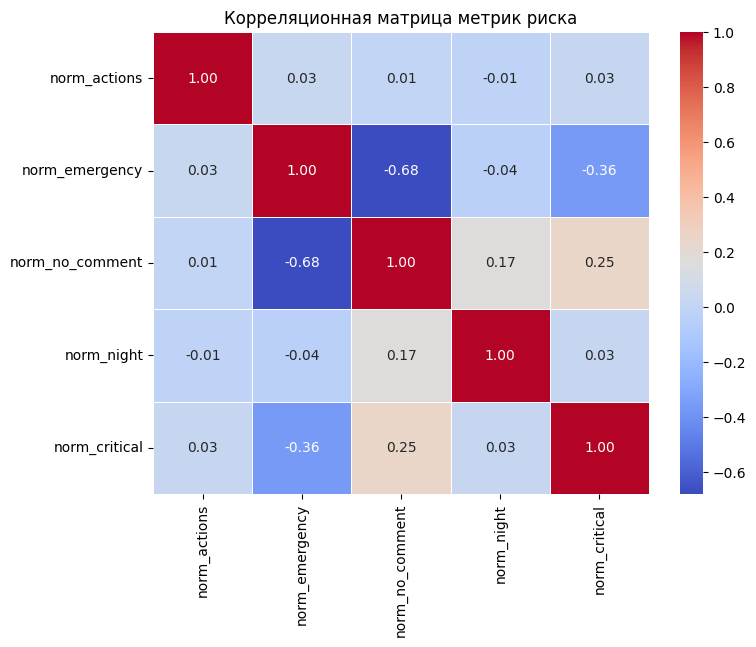

In [ ]:
# Выбираем только нормализованные метрики, которые пошли в CRS
metrics = ['norm_actions', 'norm_emergency', 'norm_no_comment', 'norm_night', 'norm_critical']
corr_matrix = user_stats[metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Корреляционная матрица метрик риска')
plt.show()

# Алгоритмический метод (Isolation Forest)

Применим алгоритм Isolation Forest для выявления многомерных аномалий. В отличие от CRS, этот метод не зависит от экспертных весов и способен находить сложные паттерны отклонений в пространстве признаков.

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. Подготавливаем признаки
features_for_ml = ['total_actions', 'emergency_ratio', 'commented_ratio',
                   'critical_ratio', 'night_ratio']
X = user_stats[features_for_ml].copy()

# 2. Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Инициализируем модель
iso_forest = IsolationForest(contamination='auto', random_state=42, n_estimators=100)

# Обучаем модель на данных
iso_forest.fit(X_scaled)

# 4. Получаем оценки и предсказания
user_stats['ml_anomaly_score'] = iso_forest.decision_function(X_scaled)
user_stats['ml_prediction'] = iso_forest.predict(X_scaled)  # 1 = норма, -1 = аномалия

# 5. Сравниваем с CRS
print(f"Топ-22 по ML-скорингу (ml_anomaly_score	ниже = более аномально):")
display(user_stats.nsmallest(22, 'ml_anomaly_score')[['user_id','total_actions', 'emergency_ratio', 'ml_anomaly_score', 'risk_score']])


Совпадение методов: 22 пользователей помечены как аномалии
Топ-22 по ML-скорингу (ml_anomaly_score	ниже = более аномально):


,user_id,total_actions,emergency_ratio,ml_anomaly_score,risk_score
96,97,326,0.340,-0.124987,0.307
87,88,310,0.323,-0.077993,0.317
4,5,3920,0.282,-0.046308,0.607
53,54,313,0.313,-0.039588,0.478
11,12,332,0.259,-0.034315,0.474
63,64,295,0.319,-0.029170,0.445
66,67,310,0.248,-0.028501,0.428
31,32,2674,0.267,-0.028315,0.486
38,39,311,0.257,-0.028069,0.460
6,7,261,0.249,-0.023500,0.237


In [ ]:
display(user_stats.nsmallest(22, 'ml_anomaly_score'))

,user_id,total_actions,unique_objects,emergency_count,business_count,commented_count,critical_count,night_count,emergency_ratio,business_ratio,...,non_business_ratio,norm_actions,norm_emergency,norm_no_comment,norm_night,norm_critical,risk_score,risk_category,ml_anomaly_score,ml_prediction
96,97,326,233,111,79,182,89,72,0.340,0.242,...,0.758,0.017764,1.000000,0.130435,0.073394,0.082759,0.307,СРЕДНИЙ,-0.124987,-1
87,88,310,239,100,98,170,81,81,0.323,0.316,...,0.684,0.013392,0.839623,0.192547,0.440367,0.000000,0.317,СРЕДНИЙ,-0.077993,-1
4,5,3920,234,1104,1024,1927,1374,1011,0.282,0.261,...,0.739,1.000000,0.452830,0.540373,0.412844,0.620690,0.607,ВЫСОКИЙ,-0.046308,-1
53,54,313,245,98,81,170,105,99,0.313,0.259,...,0.741,0.014212,0.745283,0.223602,0.944954,0.510345,0.478,ВЫСОКИЙ,-0.039588,-1
11,12,332,243,86,79,157,118,107,0.259,0.238,...,0.762,0.019404,0.235849,0.658385,1.000000,0.648276,0.474,ВЫСОКИЙ,-0.034315,-1
63,64,295,223,94,77,162,114,70,0.319,0.261,...,0.739,0.009292,0.801887,0.186335,0.220183,0.862069,0.445,СРЕДНИЙ,-0.029170,-1
66,67,310,234,77,87,157,126,89,0.248,0.281,...,0.719,0.013392,0.132075,0.453416,0.678899,1.000000,0.428,СРЕДНИЙ,-0.028501,-1
31,32,2674,245,714,705,1314,945,646,0.267,0.264,...,0.736,0.659470,0.311321,0.546584,0.266055,0.634483,0.486,ВЫСОКИЙ,-0.028315,-1
38,39,311,236,80,70,130,116,77,0.257,0.225,...,0.775,0.013665,0.216981,1.000000,0.321101,0.772414,0.460,ВЫСОКИЙ,-0.028069,-1
6,7,261,203,65,74,129,75,67,0.249,0.284,...,0.716,0.000000,0.141509,0.527950,0.403670,0.179310,0.237,НИЗКИЙ,-0.023500,-1


In [ ]:
ml_anomalies = set(user_stats[user_stats['ml_prediction'] == -1]['user_id'])
crs_high_risk = set(user_stats[user_stats['risk_category'].isin(['КРИТИЧЕСКИЙ', 'ВЫСОКИЙ'])]['user_id'])

intersection = ml_anomalies & crs_high_risk
print(f"Пользователи в зоне риска по обоим методам: {len(intersection)}")
print(f"ID пользователей: {intersection}")

Пользователи в зоне риска по обоим методам: 8
ID пользователей: {32, 5, 70, 39, 12, 21, 54, 60}
